# PTB-XL EDA — Pretraining Source for Preeclampsia Transfer
Confirm PTB-XL is format-compatible with the senior design pipeline, characterize the diagnostic-superclass labels we'll pretrain on, and lock in pretraining decisions.

- **21,837 records** from **18,885 patients**
- **12 leads**: I, II, III, aVR, aVL, aVF, V1–V6 (same order as senior design)
- **10 s** per record; available at **500 Hz** (records500/) and **100 Hz** (records100/)
- **5 diagnostic superclasses** (multi-label): NORM, MI, STTC, CD, HYP
- Official **stratified folds 1–10** — folds 9/10 are val/test

## 0. Imports & constants

In [33]:
import os
import sys
import ast
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "..")

PTBXL_DIR    = "../data/ptb-xl"
LEAD_ORDER   = ["I", "II", "III", "aVR", "aVL", "aVF",
                "V1", "V2", "V3", "V4", "V5", "V6"]
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]

FS_HR        = 500       # records500/ — high-res
FS_LR        = 100       # records100/ — low-res
N_SAMPLES_HR = 5000      # 10 s
N_SAMPLES_LR = 1000

# Senior design target format (post-decimation goal)
SD_FS = 250
SD_N  = 2500

CLASS_COLORS = {
    "NORM": "steelblue",   "MI": "tomato",
    "STTC": "mediumpurple","CD": "darkorange",
    "HYP":  "mediumseagreen",
}

## 1. Load metadata
`ptbxl_database.csv` is the master record table. `scp_codes` is a string-encoded dict of {SCP-ECG code: confidence%}. `scp_statements.csv` maps each SCP code to a 5-class `diagnostic_class`.

In [34]:
meta = pd.read_csv(os.path.join(PTBXL_DIR, "ptbxl_database.csv"), index_col="ecg_id")
meta["scp_codes"] = meta["scp_codes"].apply(ast.literal_eval)

scp = pd.read_csv(os.path.join(PTBXL_DIR, "scp_statements.csv"), index_col=0)
scp_diag = scp[scp["diagnostic"] == 1.0]   # only diagnostic codes (drop form/rhythm)

print(f"Records              : {len(meta):,}")
print(f"Patients             : {meta['patient_id'].nunique():,}")
print(f"Diagnostic SCP codes : {len(scp_diag)}")
print(f"\nMetadata columns ({len(meta.columns)}):")
print(", ".join(meta.columns))
print(f"\nFirst record's scp_codes: {meta['scp_codes'].iloc[0]}")

Records              : 21,837
Patients             : 18,885
Diagnostic SCP codes : 44

Metadata columns (27):
patient_id, age, sex, height, weight, nurse, site, device, recording_date, report, scp_codes, heart_axis, infarction_stadium1, infarction_stadium2, validated_by, second_opinion, initial_autogenerated_report, validated_by_human, baseline_drift, static_noise, burst_noise, electrodes_problems, extra_beats, pacemaker, strat_fold, filename_lr, filename_hr

First record's scp_codes: {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}


## 2. Map SCP codes → 5 diagnostic superclasses
Each ECG can map to multiple superclasses (multi-label). We'll pretrain `BaselineResNet1D` to predict all 5 with `BCEWithLogitsLoss`.

In [35]:
def aggregate_diagnostic(scp_dict):
    classes = set()
    for code in scp_dict.keys():
        if code in scp_diag.index:
            classes.add(scp_diag.loc[code, "diagnostic_class"])
    return sorted(classes)

meta["diagnostic_superclass"] = meta["scp_codes"].apply(aggregate_diagnostic)
meta["n_labels"] = meta["diagnostic_superclass"].apply(len)

flat = [c for cs in meta["diagnostic_superclass"] for c in cs]
class_counts = pd.Series(Counter(flat)).reindex(SUPERCLASSES).fillna(0).astype(int)

print("Records per diagnostic superclass (multi-label, sums > N):")
print(class_counts)

print(f"\nLabels per record:")
print(meta["n_labels"].value_counts().sort_index())
print(f"\nRecords with no diagnostic label: {(meta['n_labels'] == 0).sum():,}")

Records per diagnostic superclass (multi-label, sums > N):
NORM    9528
MI      5486
STTC    5250
CD      4907
HYP     2655
dtype: int64

Labels per record:
n_labels
0      407
1    16272
2     4079
3      920
4      159
Name: count, dtype: int64

Records with no diagnostic label: 407


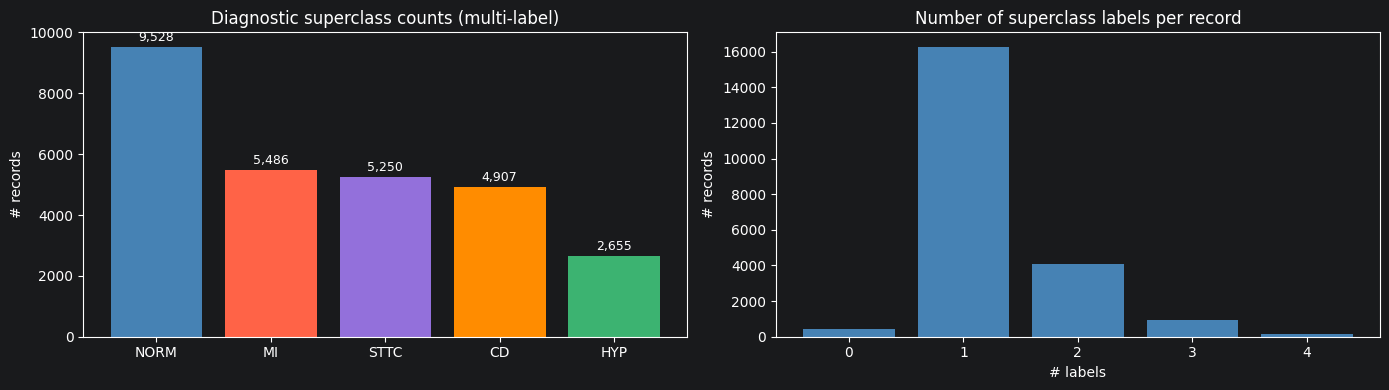

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(SUPERCLASSES, class_counts.values,
            color=[CLASS_COLORS[c] for c in SUPERCLASSES])
axes[0].set_title("Diagnostic superclass counts (multi-label)")
axes[0].set_ylabel("# records")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

labels_dist = meta["n_labels"].value_counts().sort_index()
axes[1].bar(labels_dist.index, labels_dist.values, color="steelblue")
axes[1].set_title("Number of superclass labels per record")
axes[1].set_xlabel("# labels"); axes[1].set_ylabel("# records")

plt.tight_layout(); plt.show()

## 3. Demographics
Age and sex distributions, plus the female-adult subset that most resembles the preeclampsia cohort. If we want closest-to-target pretraining, we could subset PTB-XL to female adults — but this would shrink the corpus by ~5×, so we keep the full set for pretraining and just verify the subset has reasonable label coverage.

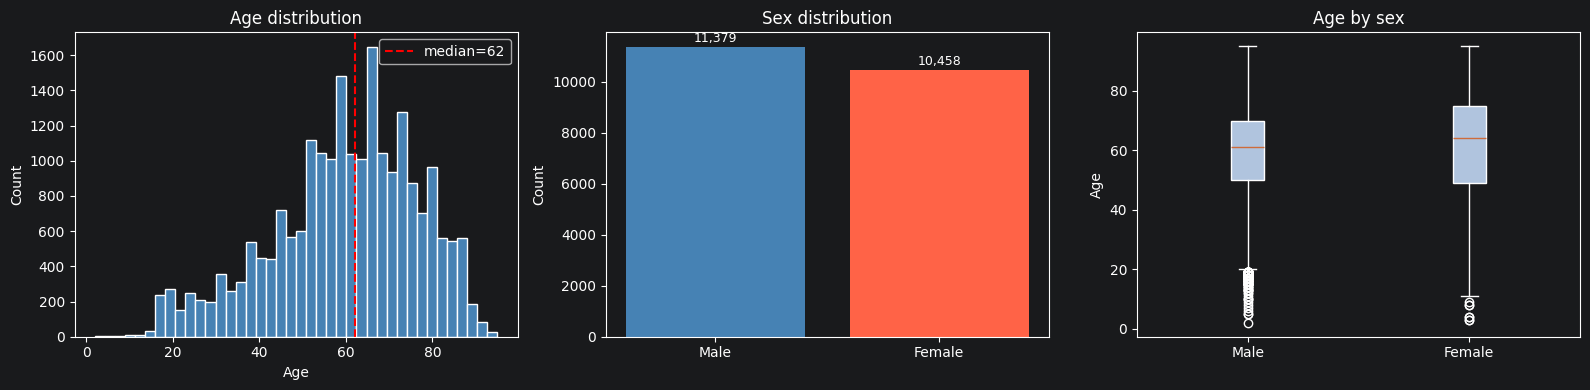


Female adults (18–50, closest demographic): 2,683 records
Class balance in this subset:
NORM    2194
MI       133
STTC     256
CD       189
HYP       68
dtype: int64


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(meta["age"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(meta["age"].median(), color="red", lw=1.5, ls="--",
                label=f"median={meta['age'].median():.0f}")
axes[0].set_title("Age distribution"); axes[0].set_xlabel("Age"); axes[0].set_ylabel("Count")
axes[0].legend()

sex_counts = meta["sex"].value_counts().rename({0: "Male", 1: "Female"})
axes[1].bar(sex_counts.index, sex_counts.values, color=["steelblue", "tomato"])
axes[1].set_title("Sex distribution"); axes[1].set_ylabel("Count")
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

age_by_sex = [meta.loc[meta["sex"] == s, "age"].dropna() for s in [0, 1]]
axes[2].boxplot(age_by_sex, tick_labels=["Male", "Female"], patch_artist=True,
                boxprops=dict(facecolor="lightsteelblue"))
axes[2].set_title("Age by sex"); axes[2].set_ylabel("Age")

plt.tight_layout(); plt.show()

# Subset closest to preeclampsia cohort
fa = meta[(meta["sex"] == 1) & (meta["age"].between(18, 50))]
fa_flat = [c for cs in fa["diagnostic_superclass"] for c in cs]
fa_counts = pd.Series(Counter(fa_flat)).reindex(SUPERCLASSES).fillna(0).astype(int)

print(f"\nFemale adults (18–50, closest demographic): {len(fa):,} records")
print("Class balance in this subset:")
print(fa_counts)

## 4. Sample loading — verify format
`wfdb` reads .dat/.hea pairs. Confirm shape, lead names, sampling rate, units, and dtype.

In [38]:
import wfdb

sample_id = meta.index[0]
fname_hr  = os.path.join(PTBXL_DIR, meta.loc[sample_id, "filename_hr"])
fname_lr  = os.path.join(PTBXL_DIR, meta.loc[sample_id, "filename_lr"])

sig_hr, fields_hr = wfdb.rdsamp(fname_hr)   # (5000, 12), dict
sig_lr, fields_lr = wfdb.rdsamp(fname_lr)   # (1000, 12), dict

print("records500/ (high-res):")
print(f"  Shape : {sig_hr.shape}    dtype: {sig_hr.dtype}    fs: {fields_hr['fs']} Hz")
print(f"  Leads : {fields_hr['sig_name']}")
print(f"  Units : {fields_hr['units']}")

print("\nrecords100/ (low-res):")
print(f"  Shape : {sig_lr.shape}    dtype: {sig_lr.dtype}    fs: {fields_lr['fs']} Hz")

# PTB-XL writes augmented leads as 'AVR/AVL/AVF'; senior design uses 'aVR/aVL/aVF'.
# Same physical leads in same order, just different casing — compare case-insensitively.
ptbxl_leads = [n.lower() for n in fields_hr["sig_name"]]
sd_leads    = [n.lower() for n in LEAD_ORDER]
assert ptbxl_leads == sd_leads, (
    f"Lead order mismatch: {fields_hr['sig_name']} vs {LEAD_ORDER}"
)
print("\n[OK] Lead order matches senior design (case-insensitive)")
print(f"     PTB-XL : {fields_hr['sig_name']}")
print(f"     SD     : {LEAD_ORDER}")

records500/ (high-res):
  Shape : (5000, 12)    dtype: float64    fs: 500 Hz
  Leads : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
  Units : ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV']

records100/ (low-res):
  Shape : (1000, 12)    dtype: float64    fs: 100 Hz

[OK] Lead order matches senior design (case-insensitive)
     PTB-XL : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
     SD     : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


## 5. Format compatibility — PTB-XL → senior design pipeline
Senior design uses `(B, 12, 2500) @ 250 Hz`. Two PTB-XL options:

| Source     | fs    | samples | path to 250 Hz × 2500 |
|------------|-------|---------|------------------------|
| records500 | 500Hz | 5000    | **decimate q=2** ✓ (preserves all freq < 100 Hz) |
| records100 | 100Hz | 1000    | upsample 2.5× — loses 50–125 Hz content. Don't use. |

**Decision:** pretrain on **records500 with stride-2 zero-phase decimation** to land exactly at `(12, 2500) @ 250 Hz`.

After 500→250 Hz decimation: (12, 2500)


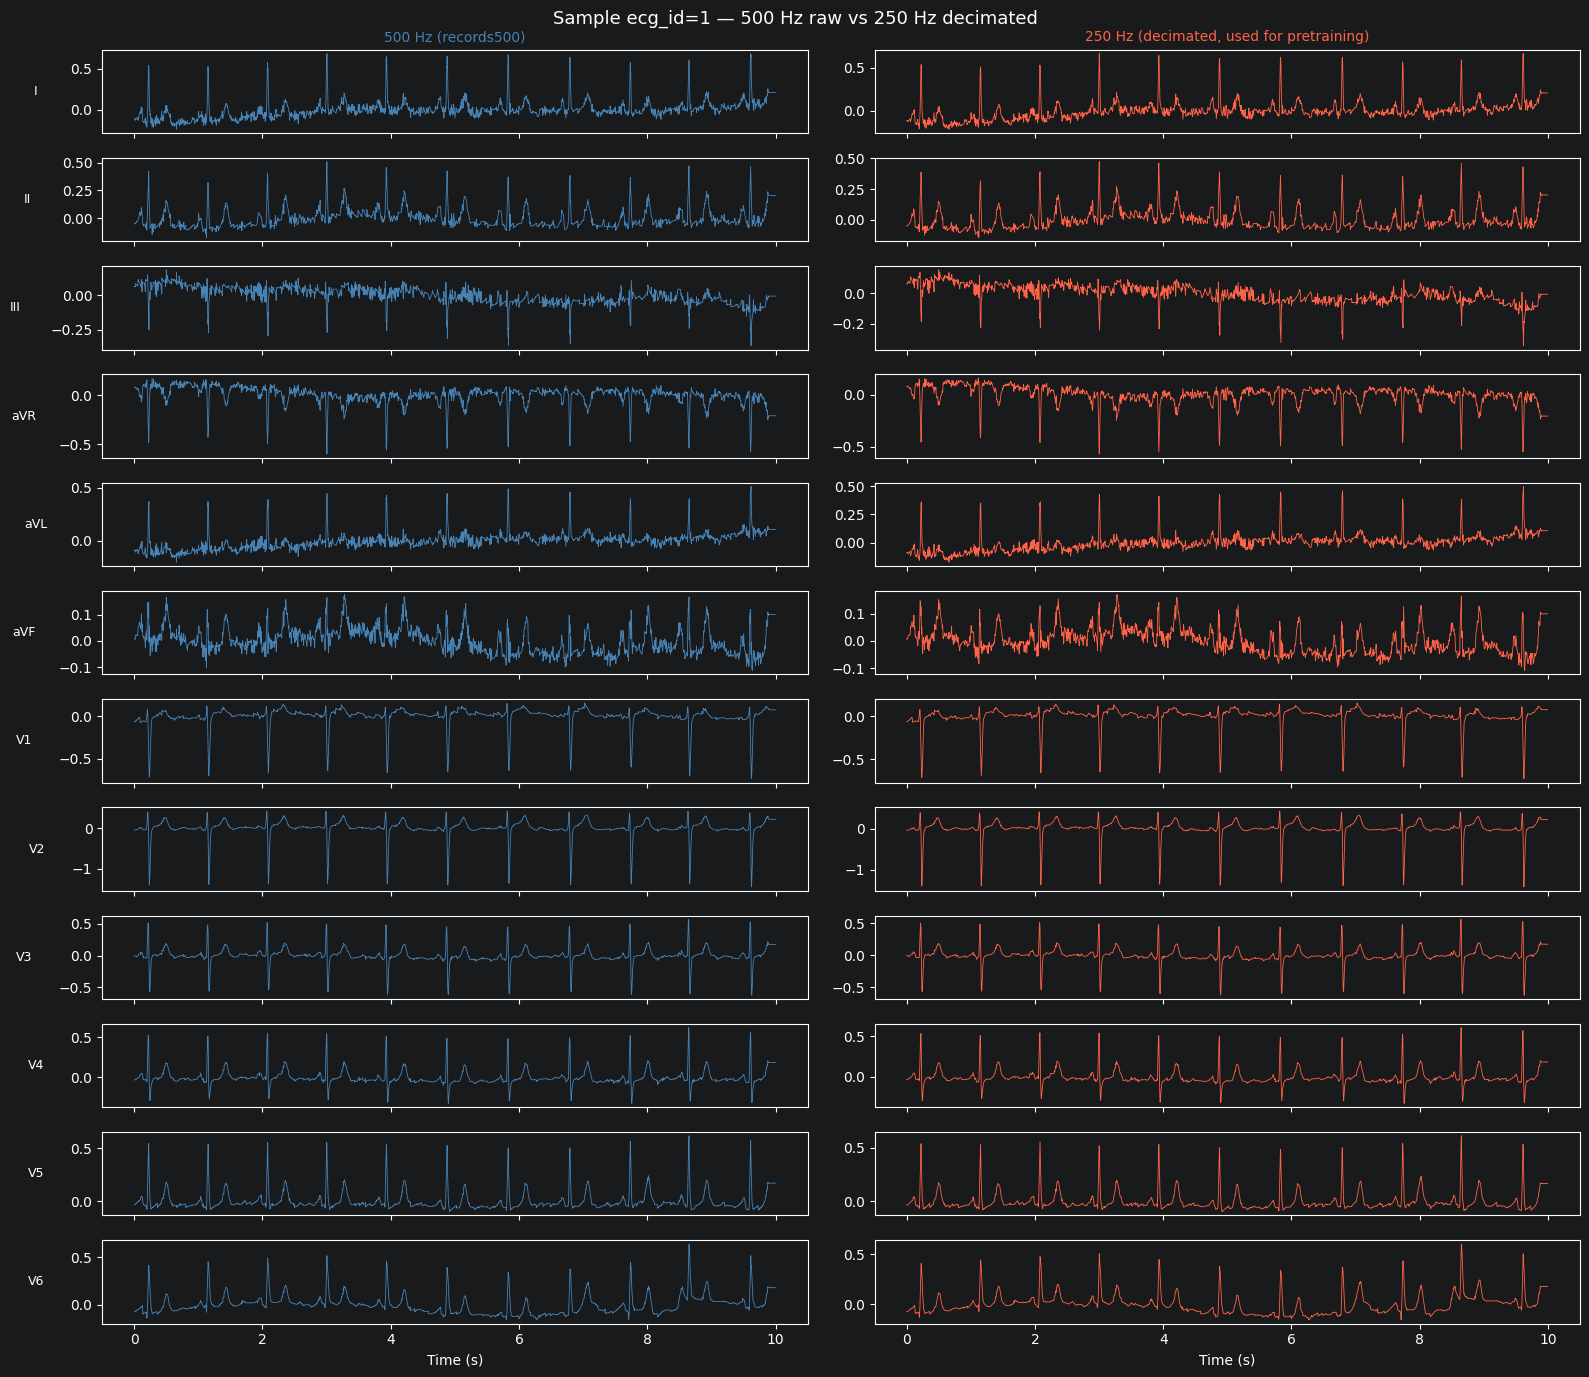

In [39]:
from scipy.signal import decimate

sig_resampled = decimate(sig_hr, q=2, axis=0, zero_phase=True).T   # (12, 2500)
print(f"After 500→250 Hz decimation: {sig_resampled.shape}")
assert sig_resampled.shape == (12, SD_N), "Shape mismatch with senior design"

t_hr = np.arange(N_SAMPLES_HR) / FS_HR
t_sd = np.arange(SD_N) / SD_FS

fig, axes = plt.subplots(12, 2, figsize=(16, 14), sharex=True)
fig.suptitle(f"Sample ecg_id={sample_id} — 500 Hz raw vs 250 Hz decimated", fontsize=13)
axes[0, 0].set_title("500 Hz (records500)",                    fontsize=10, color="steelblue")
axes[0, 1].set_title("250 Hz (decimated, used for pretraining)", fontsize=10, color="tomato")

for i, lead in enumerate(LEAD_ORDER):
    axes[i, 0].plot(t_hr, sig_hr[:, i], lw=0.6, color="steelblue")
    axes[i, 1].plot(t_sd, sig_resampled[i], lw=0.6, color="tomato")
    axes[i, 0].set_ylabel(lead, fontsize=9, rotation=0, labelpad=25, va="center")
axes[-1, 0].set_xlabel("Time (s)"); axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout(); plt.show()

## 6. Mean ± std waveform per superclass
Sample N pure-class records per superclass, decimate, z-score per-lead, plot lead II.
**What to look for:** clear morphological separation between NORM and the four pathological classes — confirms the pretraining target carries learnable signal.

In [40]:
N_PER_CLASS = 200
LEAD_VIEW   = "II"
li          = LEAD_ORDER.index(LEAD_VIEW)

def load_decimated(ecg_id):
    fname = os.path.join(PTBXL_DIR, meta.loc[ecg_id, "filename_hr"])
    sig, _ = wfdb.rdsamp(fname)
    return decimate(sig, q=2, axis=0, zero_phase=True).T   # (12, 2500)

def zscore(X):
    mu = X.mean(axis=-1, keepdims=True)
    sd = X.std(axis=-1, keepdims=True) + 1e-8
    return (X - mu) / sd

rng = np.random.default_rng(42)
class_signals = {}
for c in SUPERCLASSES:
    pure_ids = meta[meta["diagnostic_superclass"].apply(lambda cs: cs == [c])].index
    if len(pure_ids) == 0:
        continue
    ids = rng.choice(pure_ids, size=min(N_PER_CLASS, len(pure_ids)), replace=False)
    sigs = np.stack([load_decimated(i) for i in ids])         # (N, 12, 2500)
    class_signals[c] = zscore(sigs)
    print(f"  {c}: loaded {len(ids)} pure-class samples")

  NORM: loaded 200 pure-class samples
  MI: loaded 200 pure-class samples
  STTC: loaded 200 pure-class samples
  CD: loaded 200 pure-class samples
  HYP: loaded 200 pure-class samples


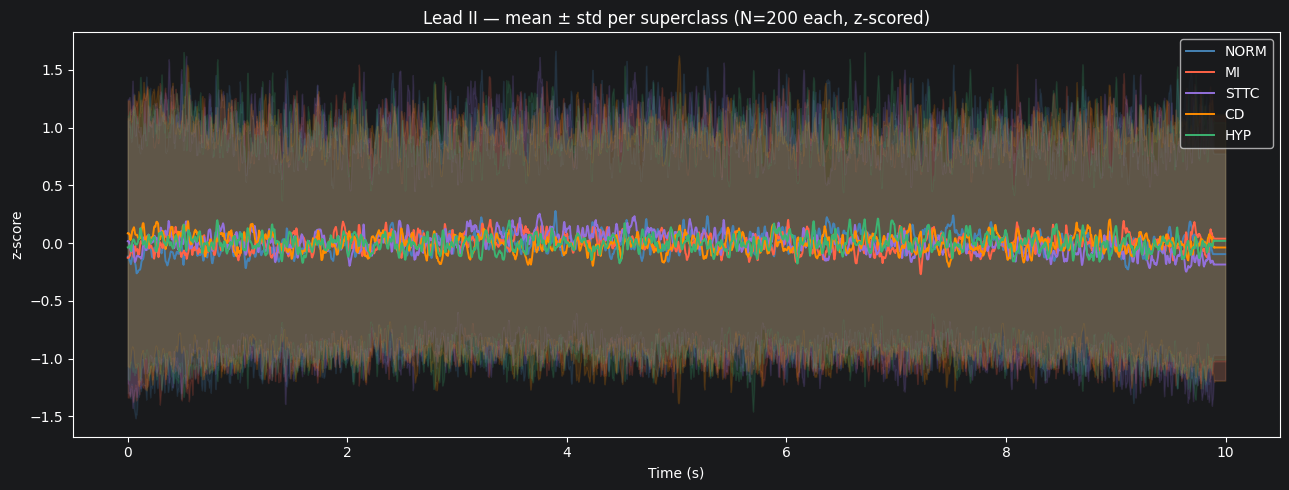

In [41]:
t = np.arange(SD_N) / SD_FS

fig, ax = plt.subplots(figsize=(13, 5))
for c, sigs in class_signals.items():
    mu  = sigs[:, li, :].mean(axis=0)
    std = sigs[:, li, :].std(axis=0)
    ax.fill_between(t, mu - std, mu + std, alpha=0.15, color=CLASS_COLORS[c])
    ax.plot(t, mu, color=CLASS_COLORS[c], lw=1.4, label=c)

ax.set_title(f"Lead {LEAD_VIEW} — mean ± std per superclass (N={N_PER_CLASS} each, z-scored)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("z-score"); ax.legend()
plt.tight_layout(); plt.show()

## 7. Power spectral density per superclass
Compare frequency content across classes — sanity check that the 0–60 Hz band carries class-discriminative power on PTB-XL just as it does on the senior design data.

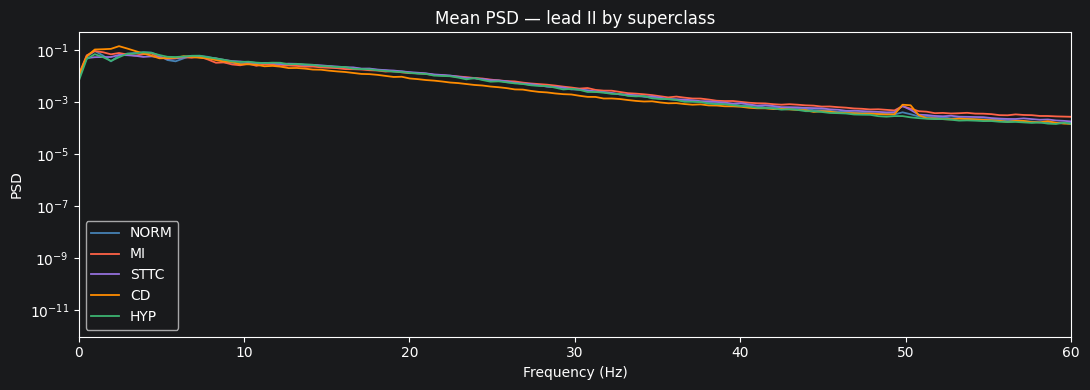

In [42]:
from scipy.signal import welch

fig, ax = plt.subplots(figsize=(11, 4))
for c, sigs in class_signals.items():
    psds = []
    for s in sigs[:, li, :]:
        f, p = welch(s, fs=SD_FS, nperseg=512)
        psds.append(p)
    ax.semilogy(f, np.stack(psds).mean(axis=0),
                color=CLASS_COLORS[c], lw=1.3, label=c)

ax.set_xlim(0, 60)
ax.set_title(f"Mean PSD — lead {LEAD_VIEW} by superclass")
ax.set_xlabel("Frequency (Hz)"); ax.set_ylabel("PSD")
ax.legend()
plt.tight_layout(); plt.show()

## 8. Stratified folds — official split
PTB-XL ships with `strat_fold` ∈ {1..10}, label-stratified, **patient-disjoint**. Standard convention used by every benchmark on this dataset:

- Folds **1–8**: training
- Fold **9**: validation
- Fold **10**: test (held out, **never** touched during pretraining)

Use this exact split so our pretrained checkpoint is comparable to published numbers.

In [43]:
fold_counts = meta["strat_fold"].value_counts().sort_index()
print("Fold sizes:")
for f, n in fold_counts.items():
    print(f"  fold {f:2d}: {n:,}")

train_n = (meta["strat_fold"] <= 8).sum()
val_n   = (meta["strat_fold"] == 9).sum()
test_n  = (meta["strat_fold"] == 10).sum()

print(f"\nProposed split:")
print(f"  Train (folds 1-8): {train_n:,}")
print(f"  Val   (fold 9   ): {val_n:,}")
print(f"  Test  (fold 10  ): {test_n:,}  ← reserve for benchmark")

p_train = set(meta.loc[meta["strat_fold"] <= 8, "patient_id"])
p_val   = set(meta.loc[meta["strat_fold"] == 9, "patient_id"])
p_test  = set(meta.loc[meta["strat_fold"] == 10, "patient_id"])

print(f"\nPatient overlap train↔val : {len(p_train & p_val)}")
print(f"Patient overlap train↔test: {len(p_train & p_test)}")
print(f"Patient overlap val↔test  : {len(p_val & p_test)}")
if not (p_train & p_val) and not (p_train & p_test) and not (p_val & p_test):
    print("[OK] Folds are patient-disjoint — safe to use as-is")

Fold sizes:
  fold  1: 2,177
  fold  2: 2,184
  fold  3: 2,194
  fold  4: 2,175
  fold  5: 2,176
  fold  6: 2,178
  fold  7: 2,178
  fold  8: 2,179
  fold  9: 2,193
  fold 10: 2,203

Proposed split:
  Train (folds 1-8): 17,441
  Val   (fold 9   ): 2,193
  Test  (fold 10  ): 2,203  ← reserve for benchmark

Patient overlap train↔val : 0
Patient overlap train↔test: 0
Patient overlap val↔test  : 0
[OK] Folds are patient-disjoint — safe to use as-is


## 9. Per-superclass coverage across folds
Confirm each fold has sufficient positives for every superclass — needed so val/test AUROC is stable.

Per-fold superclass counts:
      fold_1  fold_2  fold_3  fold_4  fold_5  fold_6  fold_7  fold_8  fold_9  \
NORM     941     967     993     928     941     932     970     935     957   
MI       550     540     529     551     563     565     551     540     544   
STTC     526     526     515     527     532     530     523     514     534   
CD       481     487     487     494     496     496     479     492     497   
HYP      263     264     264     261     265     270     265     269     271   

      fold_10  
NORM      964  
MI        553  
STTC      523  
CD        498  
HYP       263  


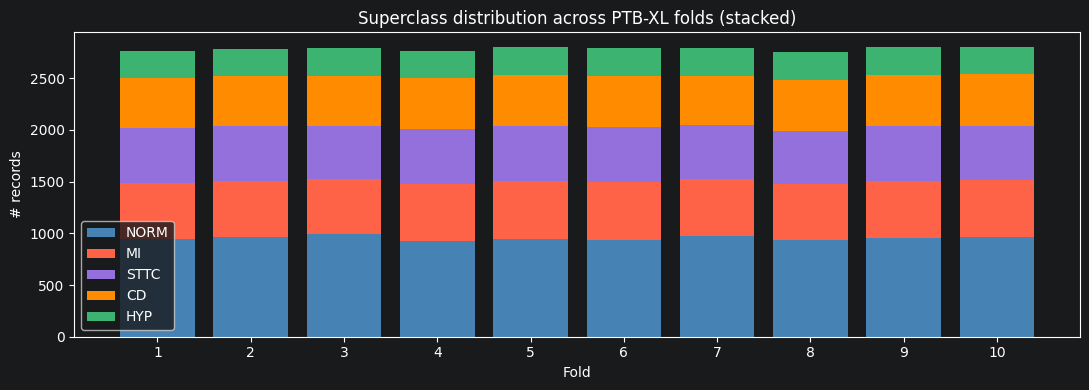

In [44]:
fold_class = []
for fold in range(1, 11):
    sub = meta[meta["strat_fold"] == fold]
    flat = [c for cs in sub["diagnostic_superclass"] for c in cs]
    counts = pd.Series(Counter(flat)).reindex(SUPERCLASSES).fillna(0).astype(int)
    fold_class.append(counts.rename(f"fold_{fold}"))
fold_class = pd.concat(fold_class, axis=1)

print("Per-fold superclass counts:")
print(fold_class)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(1, 11)
bottom = np.zeros(10)
for c in SUPERCLASSES:
    ax.bar(x, fold_class.loc[c].values, bottom=bottom,
           color=CLASS_COLORS[c], label=c)
    bottom += fold_class.loc[c].values
ax.set_xticks(x); ax.set_xlabel("Fold"); ax.set_ylabel("# records")
ax.set_title("Superclass distribution across PTB-XL folds (stacked)")
ax.legend()
plt.tight_layout(); plt.show()

## 10. Quality flags
PTB-XL annotates noise/electrode issues. We can optionally exclude them from pretraining. Magnitudes are usually small enough that keeping them adds useful augmentation.

In [45]:
flag_cols = ["baseline_drift", "static_noise", "burst_noise",
             "electrodes_problems", "pacemaker", "extra_beats"]
flag_summary = pd.Series({
    c: meta[c].notna().sum() for c in flag_cols
}, name="# records flagged").sort_values(ascending=False)
print("Quality / artifact flags (non-null = flagged):")
print(flag_summary)
print(f"\nFraction of dataset flagged for any noise issue: "
      f"{(meta[flag_cols].notna().any(axis=1)).mean():.1%}")

Quality / artifact flags (non-null = flagged):
static_noise           3262
extra_beats            1954
baseline_drift         1607
burst_noise             613
pacemaker               293
electrodes_problems      30
Name: # records flagged, dtype: int64

Fraction of dataset flagged for any noise issue: 30.3%


## 11. Format compatibility table & pretraining decisions

In [46]:
rows = [
    ("Property",      "PTB-XL",                "Senior Design",       "Action"),
    ("-" * 18,        "-" * 22,                "-" * 20,              "-" * 36),
    ("# records",     f"{len(meta):,}",        "369 (balanced)",      "~60x larger -> good pretrain corpus"),
    ("# leads",       "12",                    "12",                  "[OK] same"),
    ("Lead order",    "I,II,III,aVR..V6",      "I,II,III,aVR..V6",    "[OK] same -- no reorder"),
    ("Sampling rate", f"{FS_HR} Hz",           f"{SD_FS} Hz",         "decimate q=2 (records500)"),
    ("Samples",       f"{N_SAMPLES_HR}",       f"{SD_N}",             f"after decimate -> {SD_N} [OK]"),
    ("Duration",      "10 s",                  "10 s",                "[OK] same"),
    ("Units",         "mV",                    "ADC counts",          "z-score per-lead (same pipeline)"),
    ("Label task",    "5-class multi-label",   "binary",              "BCE pretrain -> swap head softmax"),
    ("Splits",        "folds 1-10 (official)", "3-fold patient CV",   "train 1-8, val 9, test 10"),
]
col_w = [20, 24, 22, 38]
for r in rows:
    print("  ".join(str(v).ljust(w) for v, w in zip(r, col_w)))

print("\n" + "=" * 100)
print("PRETRAINING SETUP (matches BaselineResNet1D in src/models/baseline_resnet1d.py)")
print("=" * 100)
print("""
  Architecture : BaselineResNet1D with fc replaced -> Linear(256 -> 5)
  Input        : (B, 12, 2500)              # records500 decimated by q=2
  Preprocess   : BWF (0.5 Hz HP, order 4) + per-lead z-score   # same as senior design
  Loss         : BCEWithLogitsLoss          # multi-label NORM/MI/STTC/CD/HYP
  Optimizer    : AdamW lr=1e-3, wd=1e-4, cosine schedule
  Epochs       : 30, batch=64, grad clip 1.0
  Splits       : train folds 1-8, val fold 9, test fold 10 (touch only at end)
  Save         : state_dict of stem + blocks + lead_attn  (skip fc)
  Sanity check : val macro-AUROC ~0.93 expected by epoch 30. If lower, debug
                 BEFORE attempting fine-tune on senior design data.

  Fine-tune (later step):
    1. load saved state_dict into BaselineResNet1D(n_classes=2), strict=False
    2. phase A: freeze backbone (incl. BN in eval), train fc only, lr=1e-3, ~5 ep
    3. phase B: unfreeze, discriminative LR (backbone 1e-5 / lead_attn 5e-5 / fc 1e-4)
    4. keep your existing patient-level CV folds and class imbalance handling
""")

Property              PTB-XL                    Senior Design           Action                                
------------------    ----------------------    --------------------    ------------------------------------  
# records             21,837                    369 (balanced)          ~60x larger -> good pretrain corpus   
# leads               12                        12                      [OK] same                             
Lead order            I,II,III,aVR..V6          I,II,III,aVR..V6        [OK] same -- no reorder               
Sampling rate         500 Hz                    250 Hz                  decimate q=2 (records500)             
Samples               5000                      2500                    after decimate -> 2500 [OK]           
Duration              10 s                      10 s                    [OK] same                             
Units                 mV                        ADC counts              z-score per-lead (same pipeline)      
L